In [20]:
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import json
from tqdm import tqdm
import torch
import torch.nn.functional as F
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import sys
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()

# Get token probabilities

## Main function

### Get probs for model data

In [ ]:
def get_token_probabilities(model_name, model, input_path, output_path, tokenizer, temperature=1.0, split=None):

    model.config.is_decoder = True # Model is decoder
    model.config.use_causal_mask = True # Use causal mask to avoid "looking at" future tokens

    with open(input_path, "r", encoding="utf-8") as fin: # read input file
        all_lines = fin.readlines()

    if split is not None: # read from desired line to end of file
        all_lines = all_lines[split[0]:split[1]]

    os.makedirs(os.path.dirname(output_path), exist_ok=True)


    with open(output_path, "a", encoding="utf-8") as fout:

        for i, line in tqdm(enumerate(all_lines), total=len(all_lines), desc="Processing inputs"):

            try:

                data = json.loads(line)
                response_key = [k for k in data if k.startswith('response_')][1] # to get model response
                response = data[response_key] # get response
                instruction = data["instruction"] # get instruction belonging to response

                messages = [ # put into chat format
                    {"role": "system", "content": "You are a helpful assistant."}, # system prompt
                    {"role": "user", "content": instruction}, # user prompt
                    {"role": "assistant", "content": response} # model response
                ]

                # Tokenize with chat template but don't add gen prompt
                full_text = tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=False # don't want to generate anything
                )

                full_inputs = tokenizer(full_text, return_tensors="pt").to(model.device) # tokenize the text and move to device

                with torch.no_grad():
                    outputs = model(input_ids=full_inputs["input_ids"]) # run the model on the input
                    logits = outputs.logits # get logits
                    

                scaled_logits = logits / temperature # apply temperature
                probs = torch.softmax(scaled_logits, dim=-1) # get probabilities
                log_probs = F.log_softmax(scaled_logits, dim=-1) # get log probabilities
                input_ids = full_inputs["input_ids"][0][:-1] # get input ids

                # Find where the assistant response starts
                system_and_user_text = tokenizer.apply_chat_template(
                    messages[:2],
                    tokenize=False,
                    add_generation_prompt=False
                )
                num_prompt_tokens = len(tokenizer(system_and_user_text)["input_ids"])+4 # might need to change this based on the model

                response_ids = input_ids[num_prompt_tokens:] # get response ids (after prompt tokens)

                tokens = []
                token_probs = []
                token_logprobs = []
                token_logits = []

                
                for j, token_id in enumerate(response_ids):
                    context_index = num_prompt_tokens + j - 1
                    if context_index < 0:
                        continue  # skip if there's no valid context to predict from
                    
                    prob = round(probs[0, context_index, token_id].item(), 5) # get probability of next token from previous 
                    logprob = round(log_probs[0, context_index, token_id].item(), 5) # get log probability of next token from previous 
                    logit = round(logits[0, context_index, token_id].item(), 5) # get logit of next token from previous 
                    token = tokenizer.decode(token_id) # decode token id


                    tokens.append(token) # add token to list
                    token_probs.append(prob) # add probability to list
                    token_logprobs.append(logprob) # add log probability to list
                    token_logits.append(logit) # add logit to list

                # Calculate perplexity
                avg_neg_logp = -sum(token_logprobs) / len(token_logprobs) if token_logprobs else 0
                perplexity = round(torch.exp(torch.tensor(avg_neg_logp)).item(), 5)

                model_short_name = model_name.split("/")[-1]
                data[f"token_probabilities_{model_short_name}"] = {
                    "tokens": tokens,
                    "probs": token_probs,
                    "logprobs": token_logprobs,
                    "logits": token_logits,
                    "perplexity": perplexity
                }

                fout.write(json.dumps(data, ensure_ascii=False) + "\n")

                if i % 10 == 0:
                    fout.flush()

            except Exception as e:
                print(f"Error on line {i}: {e}")
                continue

    print("Done processing inputs.")


### Get probs for human data

In [14]:
def get_token_probabilities_human(model_name, model, input_path, output_path, tokenizer, temperature=1.0, split=None):

    model.config.is_decoder = True # Model is decoder
    model.config.use_causal_mask = True # Use causal mask to avoid "looking at" future tokens

    with open(input_path, "r", encoding="utf-8") as fin: # read input file
        all_lines = fin.readlines()

    if split is not None: # read from desired line to end of file
        all_lines = all_lines[split[0]:split[1]]

    os.makedirs(os.path.dirname(output_path), exist_ok=True)


    with open(output_path, "a", encoding="utf-8") as fout:

        for i, line in tqdm(enumerate(all_lines), total=len(all_lines), desc="Processing inputs"):

            try:

                data = json.loads(line)
                response_key = "response_human"
                response = data[response_key] # get response
                instruction = data["instruction"] # get instruction belonging to response

                messages = [ # put into chat format
                    {"role": "system", "content": "You are a helpful assistant."}, # keep system prompt to make more comparable with model data perplexity
                    {"role": "user", "content": instruction}, # user prompt
                    {"role": "assistant", "content": response} # human response
                ]

                # Tokenize with chat template but don't add gen prompt
                full_text = tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=False # don't want to generate anything
                )

                full_inputs = tokenizer(full_text, return_tensors="pt").to(model.device) # tokenize the text and move to device

                with torch.no_grad():
                    outputs = model(input_ids=full_inputs["input_ids"]) # run the model on the input
                    logits = outputs.logits # get logits
                    

                scaled_logits = logits / temperature # apply temperature
                probs = torch.softmax(scaled_logits, dim=-1) # get probabilities
                log_probs = F.log_softmax(scaled_logits, dim=-1) # get log probabilities
                input_ids = full_inputs["input_ids"][0][:-1] # get input ids

                # Find where the assistant response starts
                system_and_user_text = tokenizer.apply_chat_template(
                    messages[:2],
                    tokenize=False,
                    add_generation_prompt=False
                )
                num_prompt_tokens = len(tokenizer(system_and_user_text)["input_ids"])+4 # might need to change this based on the model

                response_ids = input_ids[num_prompt_tokens:] # get response ids (after prompt tokens)

                tokens = []
                token_probs = []
                token_logprobs = []
                token_logits = []

                
                for j, token_id in enumerate(response_ids):
                    context_index = num_prompt_tokens + j - 1
                    if context_index < 0:
                        continue  # skip if there's no valid context to predict from
                    
                    prob = round(probs[0, context_index, token_id].item(), 5) # get probability of next token from previous 
                    logprob = round(log_probs[0, context_index, token_id].item(), 5) # get log probability of next token from previous 
                    logit = round(logits[0, context_index, token_id].item(), 5) # get logit of next token from previous 
                    token = tokenizer.decode(token_id) # decode token id


                    tokens.append(token) # add token to list
                    token_probs.append(prob) # add probability to list
                    token_logprobs.append(logprob) # add log probability to list
                    token_logits.append(logit) # add logit to list

                # Calculate perplexity
                avg_neg_logp = -sum(token_logprobs) / len(token_logprobs) if token_logprobs else 0
                perplexity = round(torch.exp(torch.tensor(avg_neg_logp)).item(), 5)


                data[f"token_probabilities_human"] = {
                    "tokens": tokens,
                    "probs": token_probs,
                    "logprobs": token_logprobs,
                    "logits": token_logits,
                    "perplexity": perplexity
                }

                fout.write(json.dumps(data, ensure_ascii=False) + "\n")

                if i % 10 == 0:
                    fout.flush()

            except Exception as e:
                print(f"Error on line {i}: {e}")
                continue

    print("Done processing inputs.")


## Run

In [4]:
# Load model & tokenizer

torch.set_grad_enabled(False)

model_name = "meta-llama/Llama-3.1-8B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="cuda",
    use_safetensors=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)


model-00003-of-00004.safetensors:  68%|######7   | 3.33G/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [6]:
# Calculate token probabilities & perplexity

dolly_version = 4
temperature = 1.0

input_path = f"../../Data/Finetuning/Augmented/Small/Other/dolly_train_{dolly_version}_Falcon3-10B-Instruct.jsonl"
output_path = f"../../Data/analysis/perplexity/llama_small/dolly_train_{dolly_version}_Falcon_small_PPL.jsonl"


get_token_probabilities(model_name, model, input_path, output_path, tokenizer, temperature=temperature)

'''
# Calculate PPL scores and token probs for all data in one go
for dolly_version in range(1, 5):
    input_path = f"../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_{dolly_version}_Llama.jsonl"
    output_path = f"../../Data/analysis/perplexity/llama_medium/dolly_train_{dolly_version}_Llama_medium_PPL.jsonl"
    
    get_token_probabilities(model_name, model, input_path, output_path, tokenizer, temperature=temperature)

'''

Processing inputs: 100%|██████████| 3384/3384 [06:58<00:00,  8.09it/s]

Done processing inputs.


'\n# Calculate PPL scores and token probs for all data in one go\nfor dolly_version in range(1, 5):\n    input_path = f"../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_{dolly_version}_Llama.jsonl"\n    output_path = f"../../Data/analysis/perplexity/llama_medium/dolly_train_{dolly_version}_Llama_medium_PPL.jsonl"\n    \n    get_token_probabilities(model_name, model, input_path, output_path, tokenizer, temperature=temperature)\n\n'

In [15]:
# For human data

# Calculate token probabilities & perplexity

#dolly_version = 1
temperature = 1.0

# Calculate PPL scores and token probs for all data in one go
for dolly_version in range(1, 5):
    input_path = f"../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_{dolly_version}_Llama.jsonl"
    output_path = f"../../Data/analysis/perplexity/llama_medium/dolly_train_{dolly_version}_Llama_medium_PPL.jsonl"
    
    
    get_token_probabilities_human(model_name, model, input_path, output_path, tokenizer, temperature=temperature)



Processing inputs:  22%|██▏       | 739/3377 [01:10<09:57,  4.41it/s]

Error on line 738: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 22.09 GiB of which 1.94 MiB is free. Including non-PyTorch memory, this process has 22.06 GiB memory in use. Of the allocated memory 19.92 GiB is allocated by PyTorch, and 1.87 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
Error on line 739: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 22.09 GiB of which 1.94 MiB is free. Including non-PyTorch memory, this process has 22.06 GiB memory in use. Of the allocated memory 19.91 GiB is allocated by PyTorch, and 1.88 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmen

Processing inputs: 100%|██████████| 3377/3377 [05:15<00:00, 10.70it/s]


Done processing inputs.


Processing inputs: 100%|██████████| 3377/3377 [05:11<00:00, 10.85it/s]


...

Error on line 27: CUDA out of memory. Tried to allocate 1.33 GiB. GPU 0 has a total capacity of 22.09 GiB of which 523.94 MiB is free. Including non-PyTorch memory, this process has 21.55 GiB memory in use. Of the allocated memory 19.66 GiB is allocated by PyTorch, and 1.63 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Processing inputs: 100%|██████████| 3377/3377 [05:11<00:00, 10.83it/s]


Done processing inputs.


Processing inputs: 100%|██████████| 3378/3378 [05:14<00:00, 10.75it/s]

Done processing inputs.


In [17]:
# Clearing memory 

del model  
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Analysis

## Model data

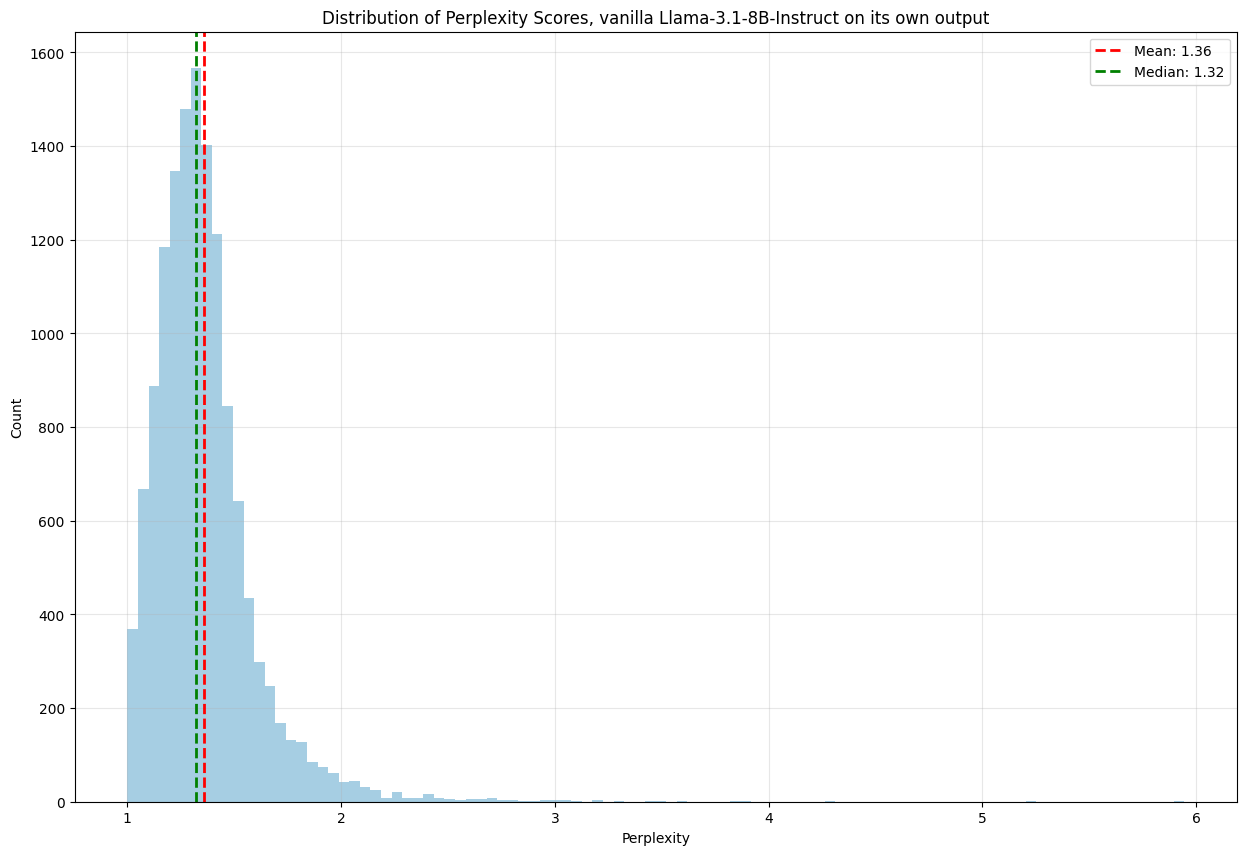

Total samples analyzed: 13505
Mean perplexity: 1.36
Median perplexity: 1.32
Min perplexity: 1.00
Max perplexity: 5.94
Number of outliers: 59


In [22]:
# Get all perplexity files
ppl_files = glob.glob("../../Data/analysis/perplexity/llama_small/*Llama_small_PPL.jsonl")


# Extract perplexity values
all_perplexities = []
for file in ppl_files:
    with open(file, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_Llama-3.1-8B-Instruct"]
            if 'perplexity' in data:
                all_perplexities.append(data['perplexity'])


# Create histogram
plt.figure(figsize=(15,10))
plt.hist(all_perplexities, bins=100, color='#a6cee3', edgecolor='none')
plt.title('Distribution of Perplexity Scores, vanilla Llama-3.1-8B-Instruct on its own output')
plt.xlabel('Perplexity')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Add mean and median lines
plt.axvline(np.mean(all_perplexities), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(all_perplexities):.2f}')
plt.axvline(np.median(all_perplexities), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(all_perplexities):.2f}')
plt.legend()

plt.savefig("../plots/perplexity/llama_small_ppl_own_output.png")

plt.show()

print(f"Total samples analyzed: {len(all_perplexities)}")
print(f"Mean perplexity: {np.mean(all_perplexities):.2f}")
print(f"Median perplexity: {np.median(all_perplexities):.2f}")
print(f"Min perplexity: {min(all_perplexities):.2f}")
print(f"Max perplexity: {max(all_perplexities):.2f}")


In [ ]:
# For single files
outliers = dict()
cutoff = 6
all_perplexities = []
with open("../../Data/analysis/perplexity/llama_small/dolly_train_4_Falcon_small_PPL.jsonl", "r") as f: 
    for i, line in enumerate(f): 
        data = json.loads(line)
        stats = data["token_probabilities_Falcon"]
        if stats["perplexity"] <= cutoff:
                all_perplexities.append(stats['perplexity'])
        if stats["perplexity"] > cutoff:
            outliers[i] = {
                "instruction": data["instruction"], 
                "response": stats["tokens"],
                "probs": stats["probs"],
                "perplexity": stats["perplexity"]
            }                        

# Create histogram
plt.figure(figsize=(15,10))
plt.hist(all_perplexities, bins=100, color='#a6cee3', edgecolor='none')
plt.title('Distribution of Perplexity Scores, vanilla Llama-3.1-8B-Instruct on Falcon-10B-Instruct output')
plt.xlabel('Perplexity')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Add mean and median lines
plt.axvline(np.mean(all_perplexities), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(all_perplexities):.2f}')
plt.axvline(np.median(all_perplexities), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(all_perplexities):.2f}')
plt.legend()


#plt.savefig("../plots/perplexity/llama_small_ppl_falcon_output.png")

plt.show()

print(f"Total samples analyzed: {len(all_perplexities)}")
print(f"Mean perplexity: {np.mean(all_perplexities):.2f}")
print(f"Median perplexity: {np.median(all_perplexities):.2f}")
print(f"Min perplexity: {min(all_perplexities):.2f}")
print(f"Max perplexity: {max(all_perplexities):.2f}")
print("Number of outliers:", len(outliers))


## Human data

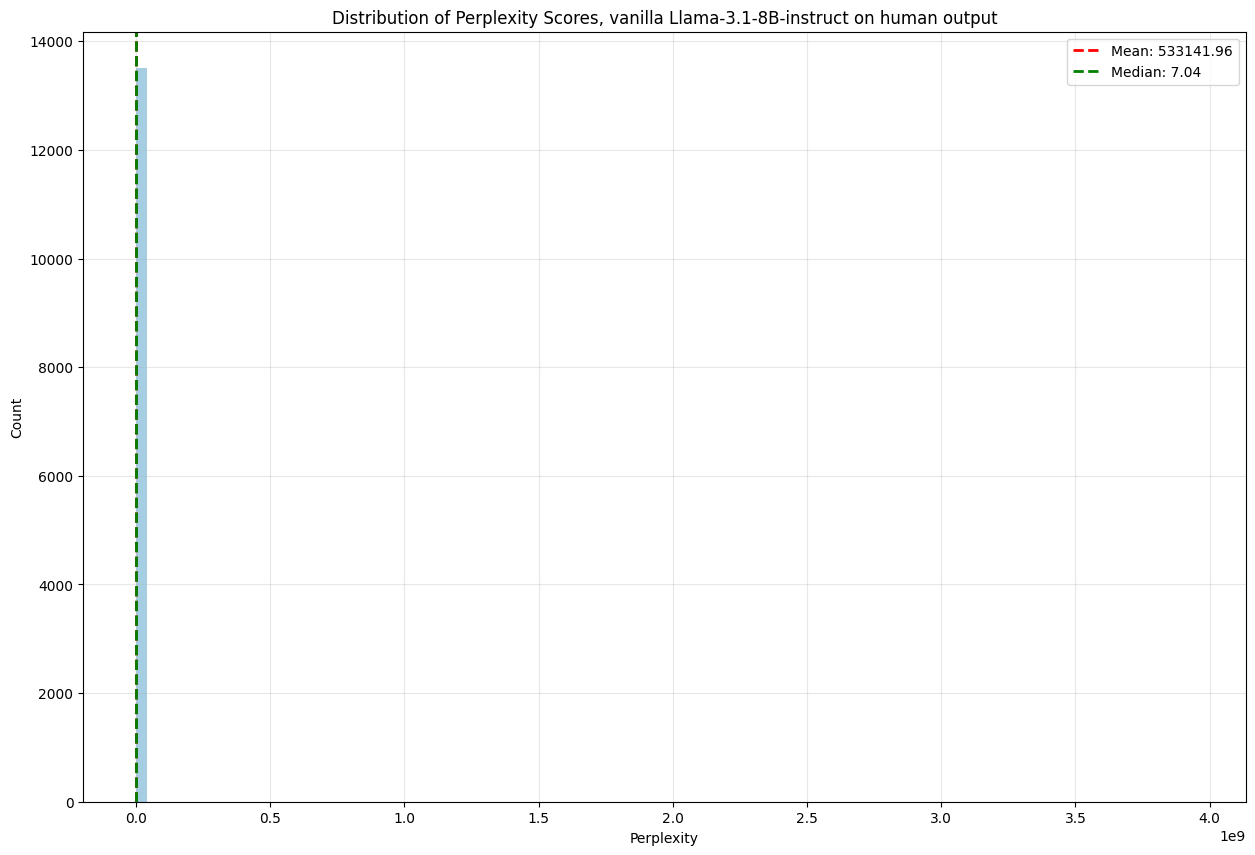

Total samples analyzed: 13505
Mean perplexity: 533141.96
Median perplexity: 7.04
Min perplexity: 1.00
Max perplexity: 3937256448.00


In [40]:
# Get all perplexity files
ppl_files = glob.glob("../../Data/analysis/perplexity/llama_small/*on_human_data_PPL.jsonl")

outliers = dict()

cutoff = 9999999999999999999999

# Extract perplexity values
all_perplexities = []
for file in ppl_files:
    with open(file, 'r') as f:
        for i, line in enumerate(f):
            data = json.loads(line)
            stats = data["token_probabilities_human"]
            if 'perplexity' in stats:
                if stats["perplexity"] <= cutoff:
                    all_perplexities.append(stats['perplexity'])
                if stats["perplexity"] > cutoff:
                    outliers[i] = {
                        "instruction": data["instruction"], 
                        "response": stats["tokens"],
                        "probs": stats["probs"],
                        "perplexity": stats["perplexity"]
                    }                        



# Create histogram
plt.figure(figsize=(15,10))
plt.hist(all_perplexities, bins=100, color='#a6cee3', edgecolor='none')
plt.title('Distribution of Perplexity Scores, vanilla Llama-3.1-8B-instruct on human output')
plt.xlabel('Perplexity')
plt.ylabel('Count')
#plt.xscale("log")
#plt.xlim(0, 30)
plt.grid(True, alpha=0.3)

# Add mean and median lines
plt.axvline(np.mean(all_perplexities), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(all_perplexities):.2f}')
plt.axvline(np.median(all_perplexities), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(all_perplexities):.2f}')
plt.legend()

plt.savefig("../plots/perplexity/llama_small_ppl_human_output_with_outliers.png")

plt.show()

print(f"Total samples analyzed: {len(all_perplexities)}")
print(f"Mean perplexity: {np.mean(all_perplexities):.2f}")
print(f"Median perplexity: {np.median(all_perplexities):.2f}")
print(f"Min perplexity: {min(all_perplexities):.2f}")
print(f"Max perplexity: {max(all_perplexities):.2f}")


In [37]:
outliers

{27: {'instruction': 'where do aliens come from',
  'response': ['space',
   ' the',
   ' final',
   ' frontier',
   ' or',
   ' is',
   ' it',
   '?'],
  'probs': [0.0, 0.00307, 0.87158, 0.99463, 0.0022, 0.14502, 0.98242, 0.14221],
  'perplexity': 77.2564},
 31: {'instruction': 'What was invented by Dr Albert Southwick in 1881',
  'response': ['Electric', ' chair'],
  'probs': [0.0, 0.00058],
  'perplexity': 111206.00781},
 60: {'instruction': 'When did money originate?',
  'response': ['120', '0', ' B', '.C', '.'],
  'probs': [0.0, 0.00787, 0.0441, 0.99902, 0.58398],
  'perplexity': 775.76056},
 64: {'instruction': 'Why are over partitioned tables poor data layout strategy',
  'response': ['Over',
   '-part',
   'ition',
   'ing',
   ' creates',
   ' physical',
   ' boundaries',
   ' beyond',
   ' which',
   ' the',
   ' file',
   ' comp',
   'action',
   ' and',
   ' z',
   '-order',
   'ing',
   ' aren',
   '’t',
   ' effective',
   ' and',
   ' you',
   '’re',
   ' still',
   ' le

In [20]:
# Get all perplexity files
ppl_files = glob.glob("../../Data/analysis/perplexity/llama_small/*on_human_data_PPL.jsonl")

# Extract perplexity values with their source data
perplexities_with_data = []
for file in ppl_files:
    with open(file, 'r') as f:
        for line in f:
            data = json.loads(line)
            ppl_data = data["token_probabilities_human"]
            if 'perplexity' in ppl_data:
                perplexities_with_data.append({
                    'perplexity': ppl_data['perplexity'],
                    'instruction': data['instruction'],
                    'response': data['response_human']
                })

# Sort by perplexity in descending order and get top 10
top_10 = sorted(perplexities_with_data, key=lambda x: x['perplexity'], reverse=True)[:10]

print("Top 10 highest perplexity values:")
print("-" * 80)
for i, item in enumerate(top_10, 1):
    print(f"\n{i}. Perplexity: {item['perplexity']:.2f}")
    print(f"Instruction: {item['instruction']}")
    print(f"Response: {item['response']}")
    print("-" * 80)


Top 10 highest perplexity values:
--------------------------------------------------------------------------------

1. Perplexity: 3937256448.00
Instruction: Tesrt
Response: Answer
--------------------------------------------------------------------------------

2. Perplexity: 1566141440.00
Instruction: Horsfieldia nervosa is a species of plant in the family Myristicaceae. It is a tree endemic to Borneo where it is confined to Sarawak.

Is Horsfieldia nervos a plant or animal?
Response: plant
--------------------------------------------------------------------------------

3. Perplexity: 673581312.00
Instruction: According to the official Department of Corrections web site, SCI Dallas (Luzerne County, 10 miles from Wilkes-Barre) was opened in 1960 as an institution for defective delinquents. After the state Supreme Court decision of 1966 voided the concept of "defective delinquents," Dallas, like Huntingdon, became an adult institution. It now is a medium-security facility for men.

Do

## Perplexity comparison small vs medium Llama

In [29]:
# Get all perplexity files
ppl_model_small = glob.glob("../../Data/analysis/perplexity/llama_small/*Llama_small_PPL.jsonl")
ppl_human_small = glob.glob("../../Data/analysis/perplexity/llama_small/*on_human_data_PPL.jsonl")

ppl_model_medium = glob.glob("../../Data/analysis/perplexity/llama_medium/*Llama_medium_PPL.jsonl")
ppl_human_medium = glob.glob("../../Data/analysis/perplexity/llama_medium/*on_human_data_PPL.jsonl")

file_command_medium = "../../Data/analysis/perplexity/llama_medium/dolly_train_4_Command_medium_PPL.jsonl"
file_falcon_small = "../../Data/analysis/perplexity/llama_small/dolly_train_4_Falcon_small_PPL.jsonl"

file_multi_small = "../../Data/analysis/perplexity/llama_small/dolly_train_all_multi.jsonl"

# Extract perplexity values
perplexities_model_small = []
perplexities_human_small = []
perplexities_model_medium = []
perplexities_human_medium = []
perplexities_command_medium = []
perplexities_falcon_small = []
perplexities_multi_small = []

for file_model_small, file_human_small, file_model_medium, file_human_medium in zip(ppl_model_small, ppl_human_small, ppl_model_medium, ppl_human_medium):
    with open(file_model_small, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_Llama-3.1-8B-Instruct"]
            if 'perplexity' in data:
                perplexities_model_small.append(data['perplexity'])

    with open(file_human_small, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_human"]
            if 'perplexity' in data:
                perplexities_human_small.append(data['perplexity'])

    with open(file_model_medium, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_Llama-3.1-70B-Instruct"]
            if 'perplexity' in data:
                perplexities_model_medium.append(data['perplexity'])

    with open(file_human_medium, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_human"]
            if 'perplexity' in data:
                perplexities_human_medium.append(data['perplexity'])


with open(file_command_medium, 'r') as f:
    for line in f:
        data = json.loads(line)
        data = data["token_probabilities_Llama-3.1-70B-Instruct"]
        if 'perplexity' in data:
            perplexities_command_medium.append(data['perplexity'])

with open(file_falcon_small, 'r') as f:
    for line in f:
        data = json.loads(line)
        data = data["token_probabilities_Falcon"]
        if 'perplexity' in data:
            perplexities_falcon_small.append(data['perplexity'])

with open(file_multi_small, 'r') as f:
    for line in f:
        data = json.loads(line)
        response_key = [k for k in data if k.startswith('token_probabilities_')][0] 
        data = data[response_key]
        if 'perplexity' in data:
            perplexities_multi_small.append(data['perplexity'])
            


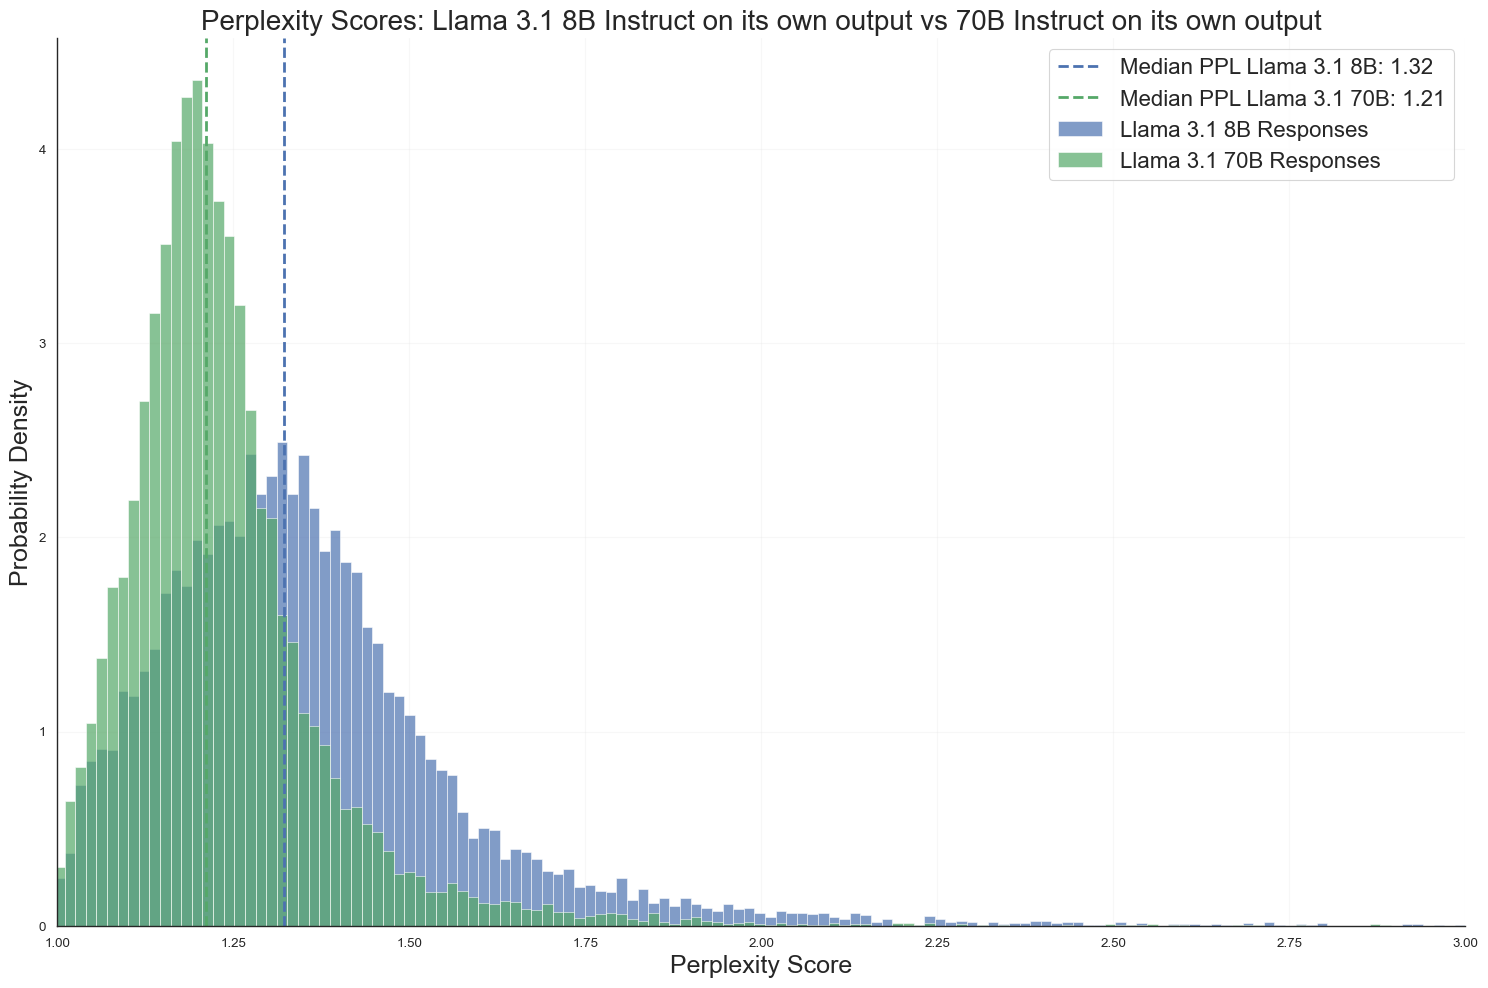

In [46]:
xmin = 1
xmax = 3
# Plot human vs model perplexity scores for Llama medium
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
model_small_median = np.median(perplexities_model_small)
model_medium_median = np.median(perplexities_model_medium)

# Plot histograms
sns.histplot(perplexities_model_small, bins=bins, alpha=0.7, label='Llama 3.1 8B Responses', color=sns.color_palette()[0], stat='density')  # Dodger Blue
sns.histplot(perplexities_model_medium, bins=bins, alpha=0.7, label='Llama 3.1 70B Responses', color=sns.color_palette()[1], stat='density')  # Tomato Red

# Add vertical lines for median values
plt.axvline(x=model_small_median, color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL Llama 3.1 8B: {model_small_median:.2f}')
plt.axvline(x=model_medium_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL Llama 3.1 70B: {model_medium_median:.2f}')

# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Perplexity Scores: Llama 3.1 8B Instruct on its own output vs 70B Instruct on its own output', fontsize=20)
plt.xlim(xmin, xmax)
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_small_vs_medium_own_output.png")

# Show the plot
plt.tight_layout()
plt.show()


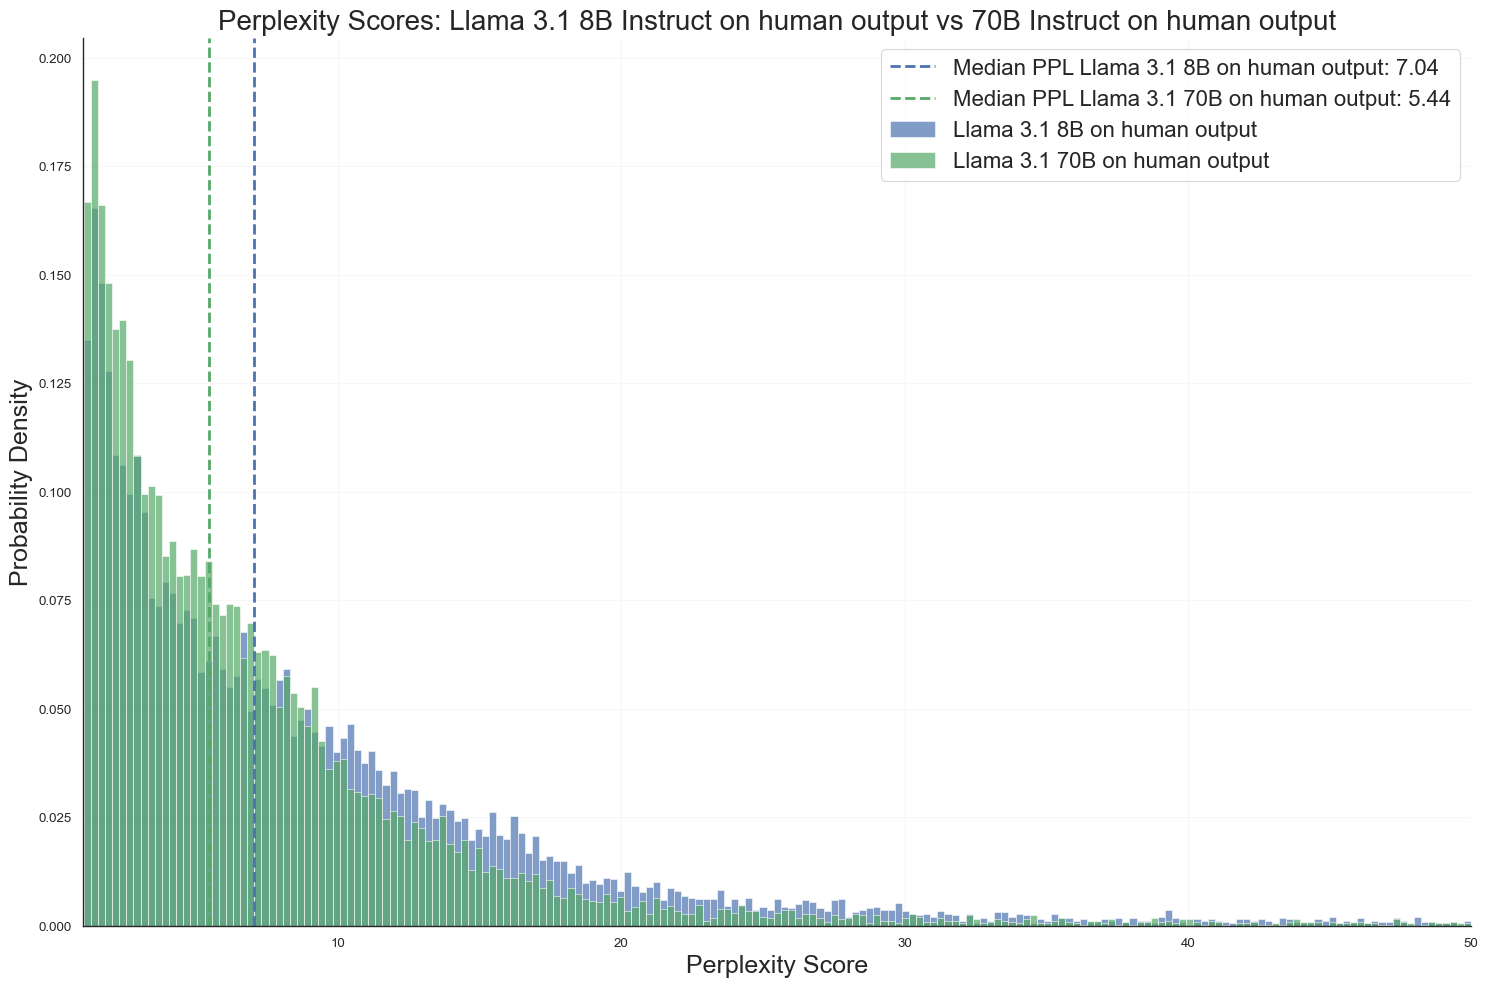

In [47]:
xmin = 1
xmax = 50
# Plot human vs model perplexity scores for Llama medium
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
human_small_median = np.median(perplexities_human_small)
human_medium_median = np.median(perplexities_human_medium)

# Plot histograms
sns.histplot(perplexities_human_small, bins=bins, alpha=0.7, label='Llama 3.1 8B on human output', color=sns.color_palette()[0], stat='density')  # Dodger Blue
sns.histplot(perplexities_human_medium, bins=bins, alpha=0.7, label='Llama 3.1 70B on human output', color=sns.color_palette()[1], stat='density')  # Tomato Red

# Add vertical lines for median values
plt.axvline(x=human_small_median, color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL Llama 3.1 8B on human output: {human_small_median:.2f}')
plt.axvline(x=human_medium_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL Llama 3.1 70B on human output: {human_medium_median:.2f}')

# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Perplexity Scores: Llama 3.1 8B Instruct on human output vs 70B Instruct on human output', fontsize=20)
plt.xlim(xmin, xmax)
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_small_vs_medium_human_output.png")

# Show the plot
plt.tight_layout()
plt.show()


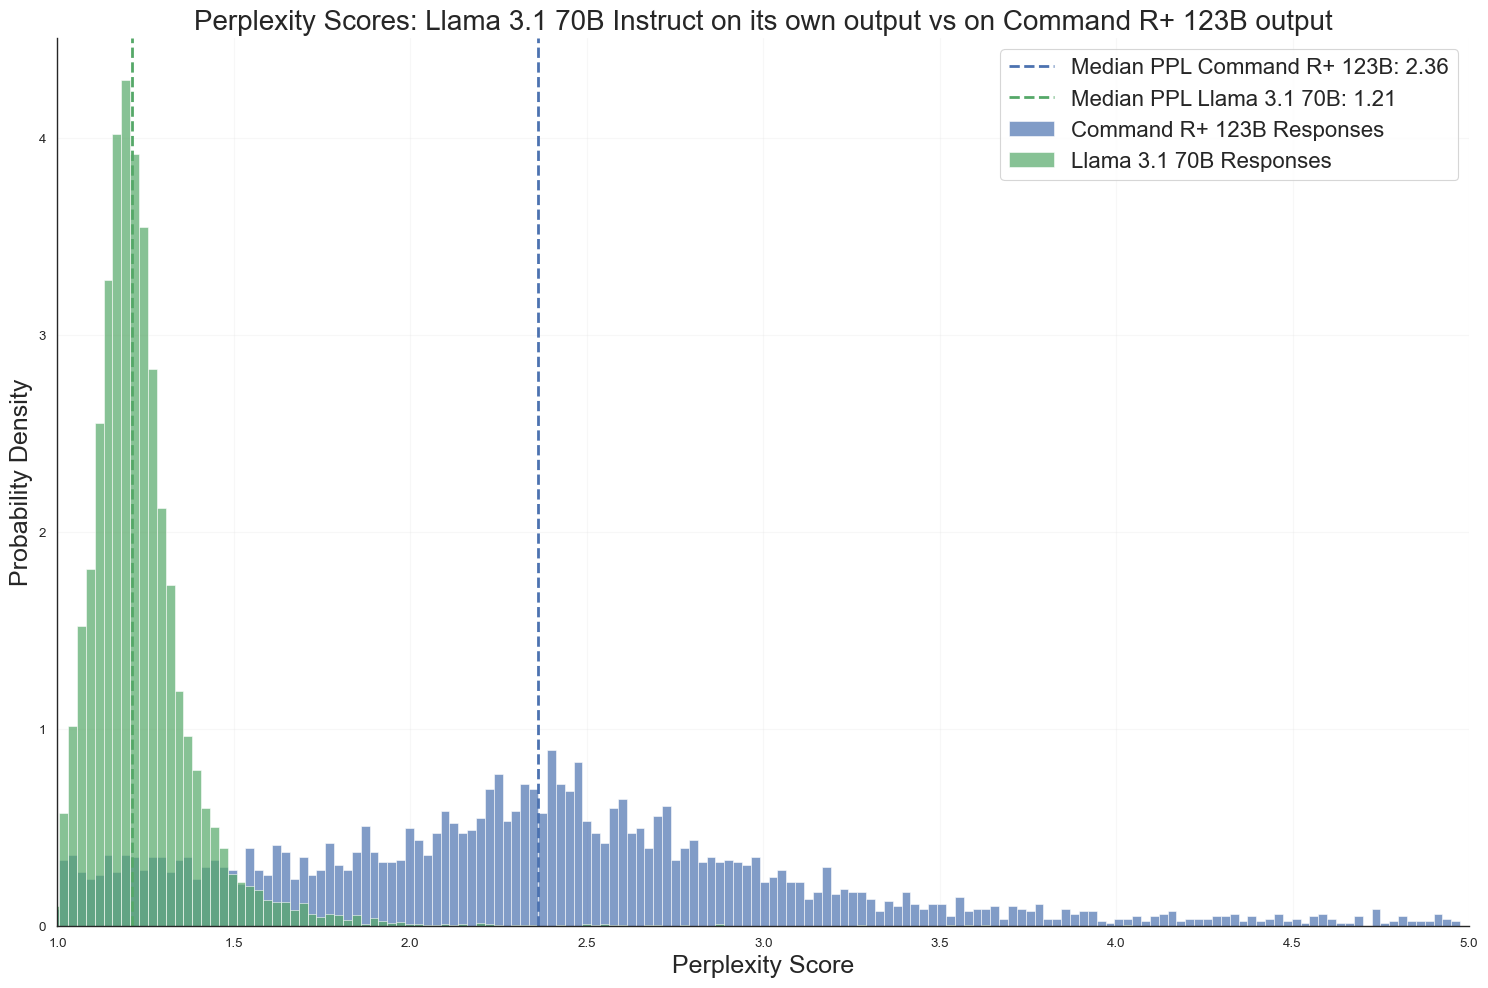

In [48]:
xmin = 1
xmax = 5
# Plot command vs llama perplexity scores for Llama medium
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
command_medium_median = np.median(perplexities_command_medium)
model_medium_median = np.median(perplexities_model_medium)

# Plot histograms
sns.histplot(perplexities_command_medium, bins=bins, alpha=0.7, label='Command R+ 123B Responses', color=sns.color_palette()[0], stat='density')  # Dodger Blue
sns.histplot(perplexities_model_medium, bins=bins, alpha=0.7, label='Llama 3.1 70B Responses', color=sns.color_palette()[1], stat='density')  # Tomato Red

# Add vertical lines for median values
plt.axvline(x=command_medium_median , color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL Command R+ 123B: {command_medium_median:.2f}')
plt.axvline(x=model_medium_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL Llama 3.1 70B: {model_medium_median:.2f}')

# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Perplexity Scores: Llama 3.1 70B Instruct on its own output vs on Command R+ 123B output', fontsize=20)
plt.xlim(xmin, xmax)
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_medium_own_vs_command_output.png")

# Show the plot
plt.tight_layout()
plt.show()


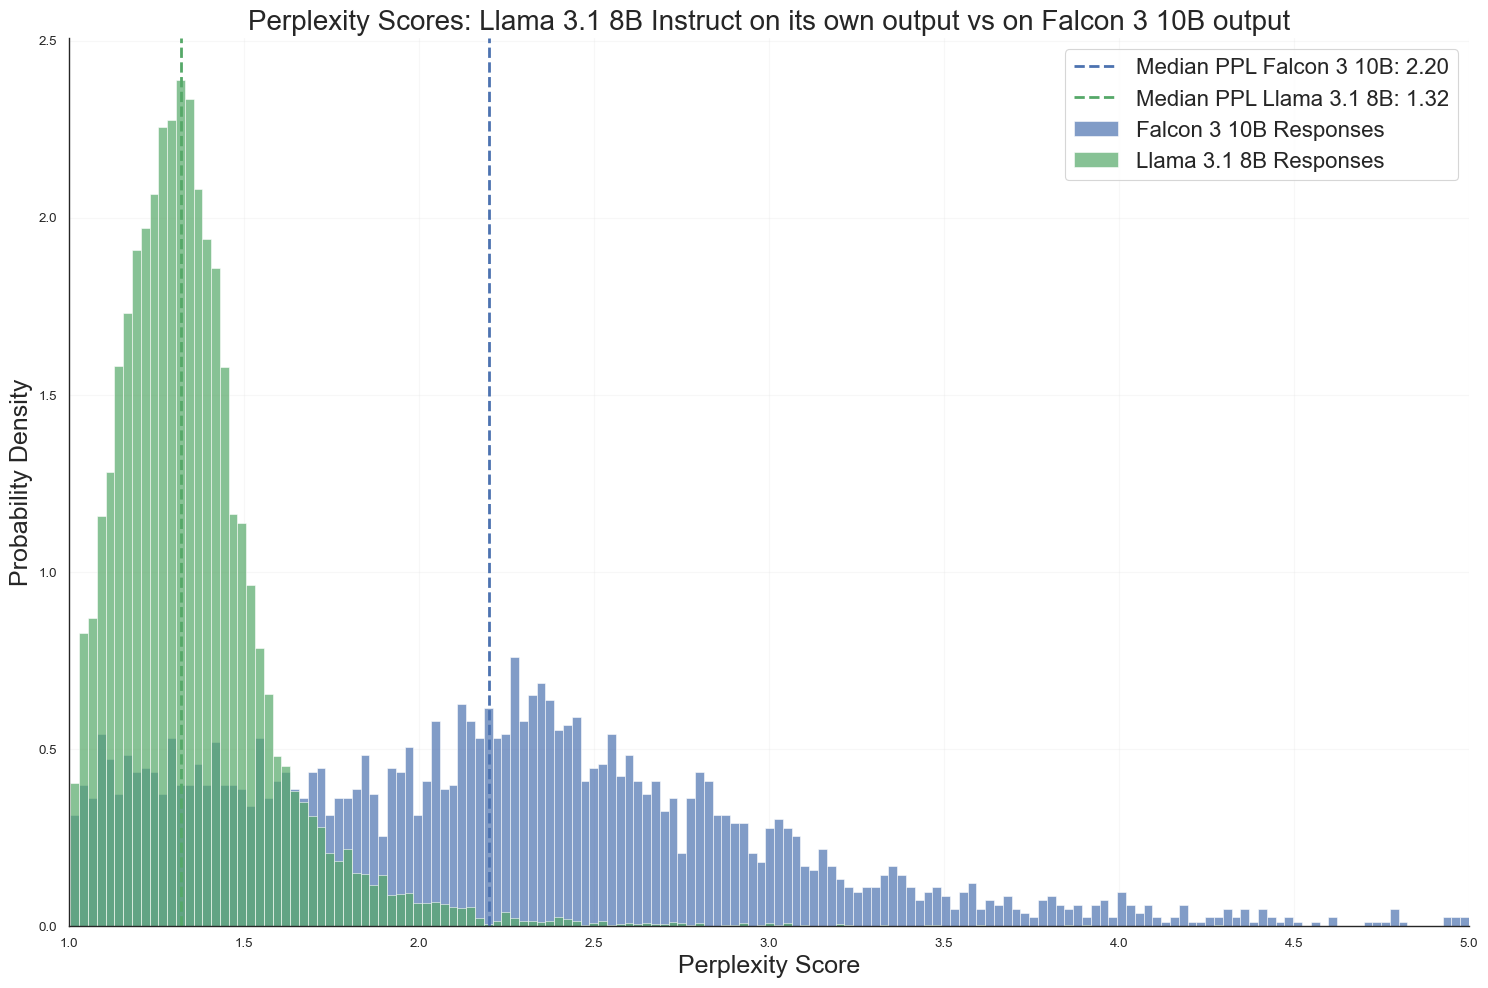

In [49]:
xmin = 1
xmax = 5
# Plot falcon vs llama perplexity scores for Llama small
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
falcon_small_median = np.median(perplexities_falcon_small)
model_small_median = np.median(perplexities_model_small)

# Plot histograms
sns.histplot(perplexities_falcon_small, bins=bins, alpha=0.7, label='Falcon 3 10B Responses', color=sns.color_palette()[0], stat='density')  # Dodger Blue
sns.histplot(perplexities_model_small, bins=bins, alpha=0.7, label='Llama 3.1 8B Responses', color=sns.color_palette()[1], stat='density')  # Tomato Red

# Add vertical lines for median values
plt.axvline(x=falcon_small_median , color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL Falcon 3 10B: {falcon_small_median:.2f}')
plt.axvline(x=model_small_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL Llama 3.1 8B: {model_small_median:.2f}')

# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Perplexity Scores: Llama 3.1 8B Instruct on its own output vs on Falcon 3 10B output', fontsize=20)
plt.xlim(xmin, xmax)
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_small_own_vs_falcon_output.png")

# Show the plot
plt.tight_layout()
plt.show()


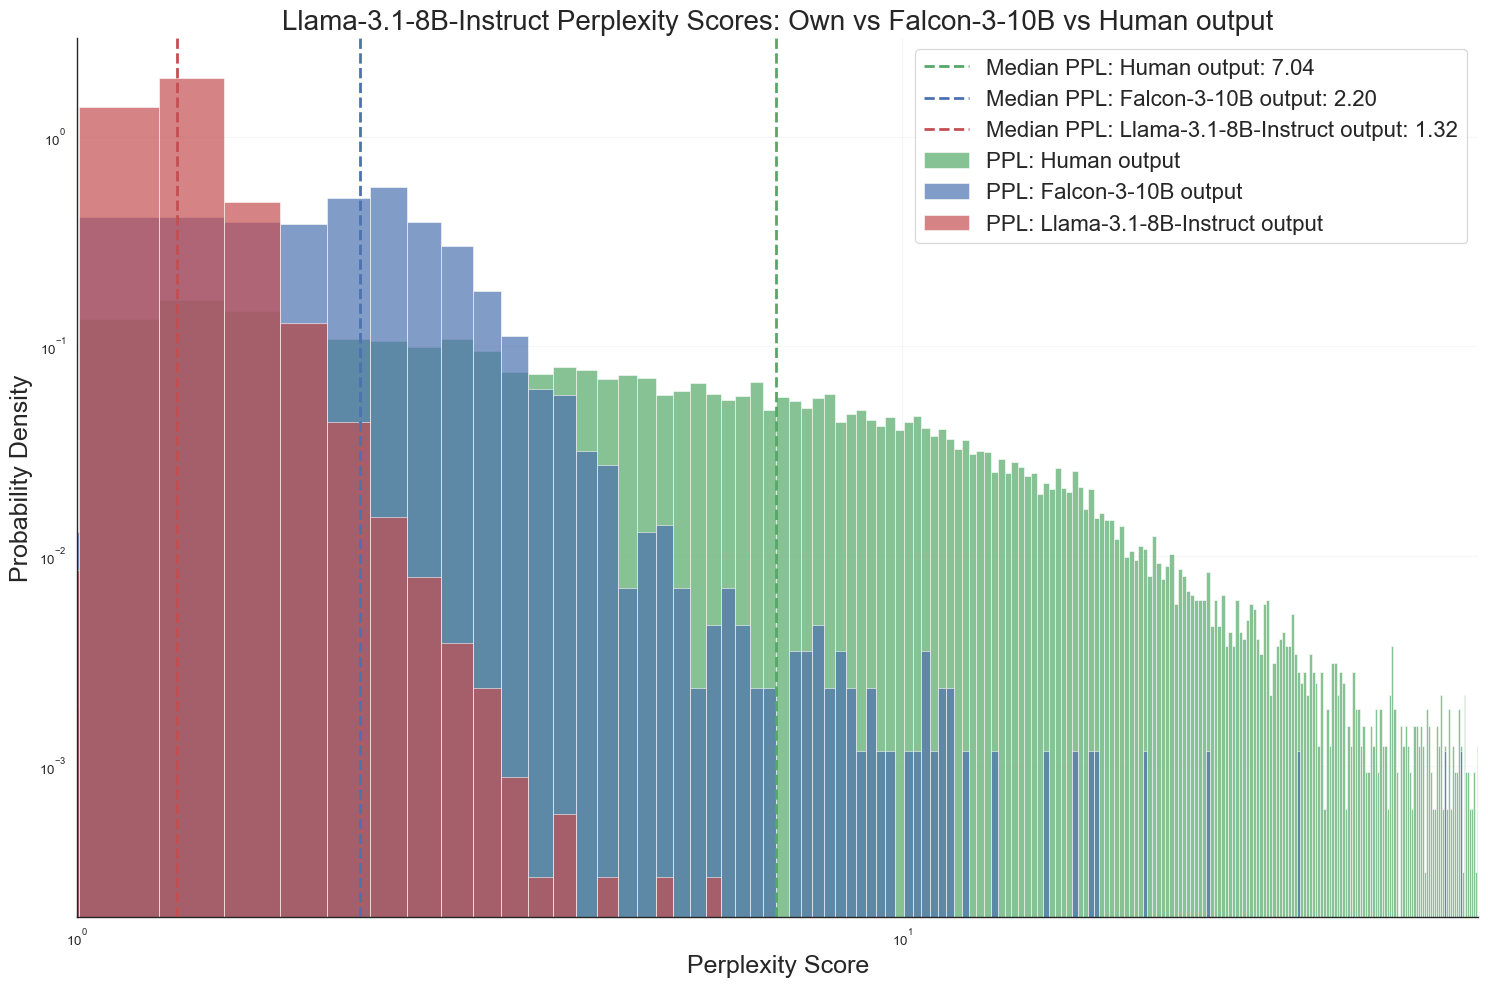

In [50]:
xmin = 1
xmax = 50
# Plot falcon vs llama perplexity scores for Llama small
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
falcon_small_median = np.median(perplexities_falcon_small)
model_small_median = np.median(perplexities_model_small)
human_small_median = np.median(perplexities_human_small)

# Plot histograms
sns.histplot(perplexities_human_small, bins=bins, alpha=0.7, label='PPL: Human output', color=sns.color_palette()[1], stat='density') 
sns.histplot(perplexities_falcon_small, bins=bins, alpha=0.7, label='PPL: Falcon-3-10B output', color=sns.color_palette()[0], stat='density')  
sns.histplot(perplexities_model_small, bins=bins, alpha=0.7, label='PPL: Llama-3.1-8B-Instruct output', color=sns.color_palette()[2], stat='density')  
 
# Add vertical lines for median values
plt.axvline(x=human_small_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL: Human output: {human_small_median:.2f}')
plt.axvline(x=falcon_small_median , color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL: Falcon-3-10B output: {falcon_small_median:.2f}')
plt.axvline(x=model_small_median, color=sns.color_palette()[2], linestyle='--', linewidth=2, label=f'Median PPL: Llama-3.1-8B-Instruct output: {model_small_median:.2f}')


# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Llama-3.1-8B-Instruct Perplexity Scores: Own vs Falcon-3-10B vs Human output', fontsize=20)
plt.xlim(xmin, xmax)
plt.yscale('log')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_small_own_vs_falcon_vs_human_output.png")

# Show the plot
plt.tight_layout()
plt.show()


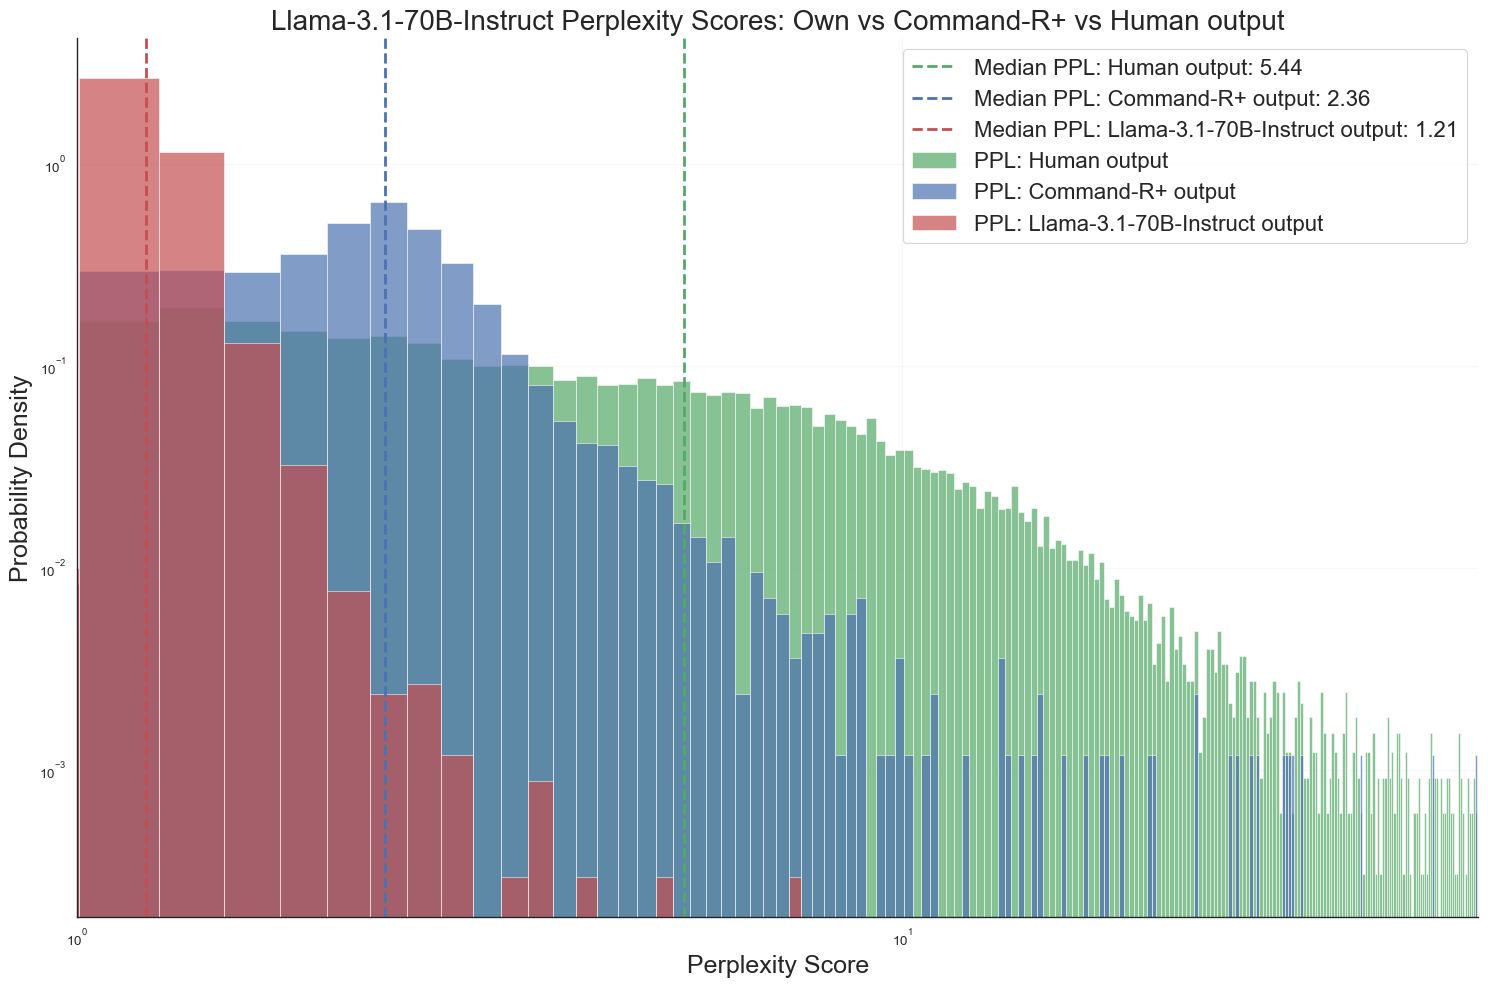

In [51]:
xmin = 1
xmax = 50
# Plot command vs llama perplexity scores for Llama medium
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
command_medium_median = np.median(perplexities_command_medium)
model_medium_median = np.median(perplexities_model_medium)
human_medium_median = np.median(perplexities_human_medium)

# Plot histograms
sns.histplot(perplexities_human_medium, bins=bins, alpha=0.7, label='PPL: Human output', color=sns.color_palette()[1], stat='density') 
sns.histplot(perplexities_command_medium, bins=bins, alpha=0.7, label='PPL: Command-R+ output', color=sns.color_palette()[0], stat='density')  
sns.histplot(perplexities_model_medium, bins=bins, alpha=0.7, label='PPL: Llama-3.1-70B-Instruct output', color=sns.color_palette()[2], stat='density')  
 
# Add vertical lines for median values
plt.axvline(x=human_medium_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL: Human output: {human_medium_median:.2f}')
plt.axvline(x=command_medium_median, color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL: Command-R+ output: {command_medium_median:.2f}')
plt.axvline(x=model_medium_median, color=sns.color_palette()[2], linestyle='--', linewidth=2, label=f'Median PPL: Llama-3.1-70B-Instruct output: {model_medium_median:.2f}')


# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Llama-3.1-70B-Instruct Perplexity Scores: Own vs Command-R+ vs Human output', fontsize=20)
plt.xlim(xmin, xmax)
plt.yscale('log')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_medium_own_vs_command_vs_human_output.png")

# Show the plot
plt.tight_layout()
plt.show()


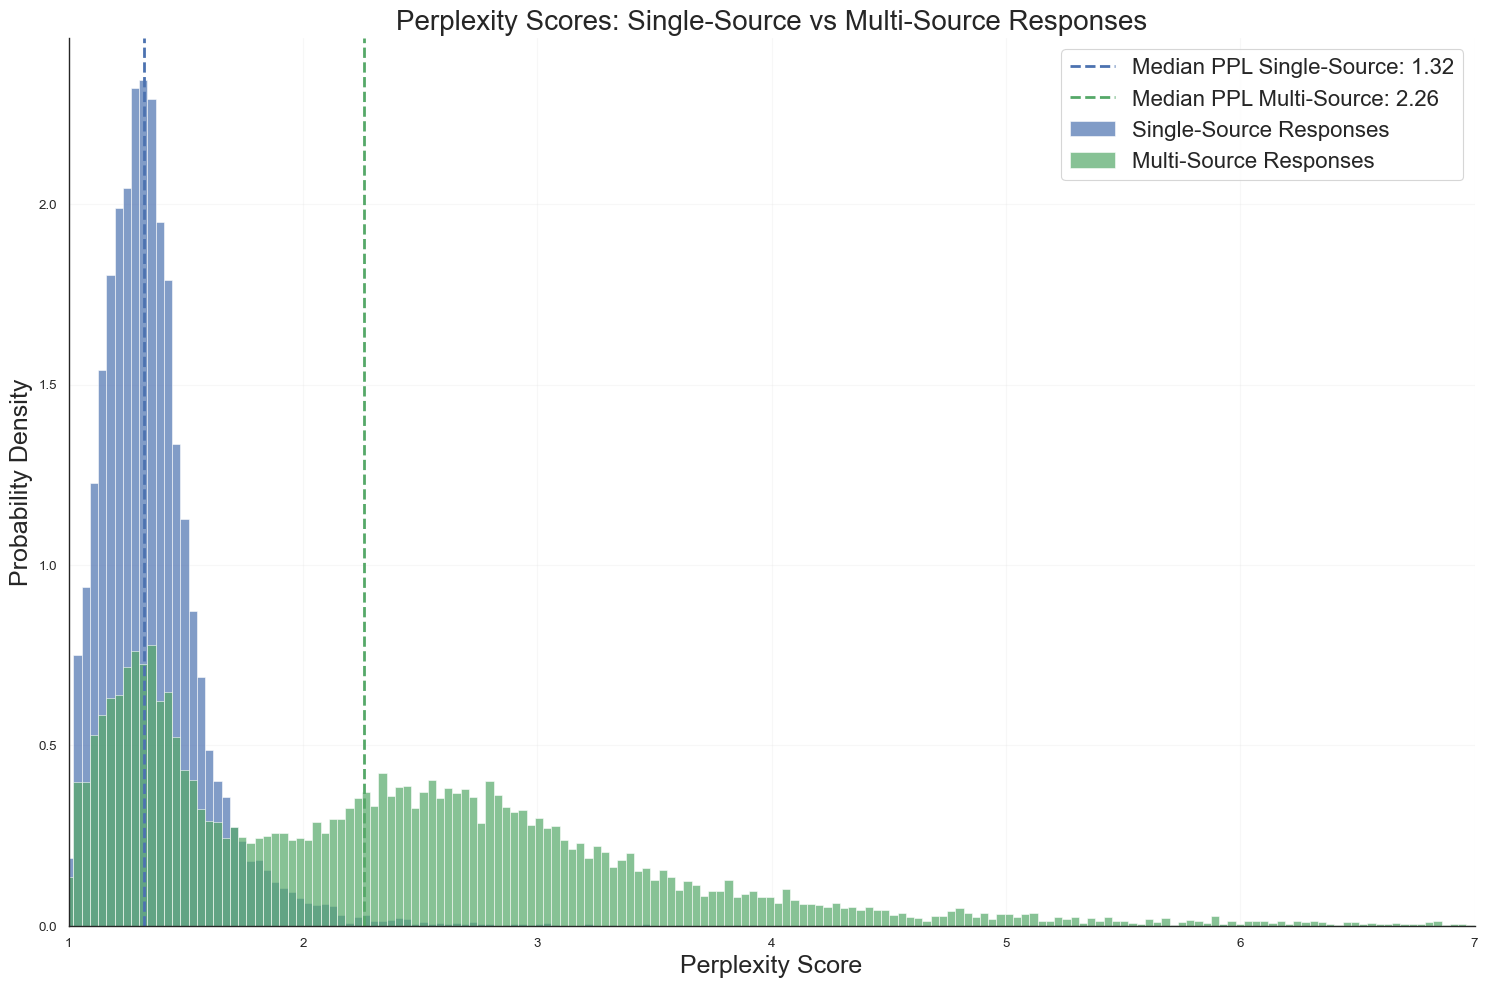

In [52]:
xmin = 1
xmax = 7
# Plot human vs model perplexity scores for Llama medium
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, xmax, 200)  

# Calculate medians
model_small_median = np.median(perplexities_model_small)
multi_small_median = np.median(perplexities_multi_small)

# Plot histograms
sns.histplot(perplexities_model_small, bins=bins, alpha=0.7, label='Single-Source Responses', color=sns.color_palette()[0], stat='density')  # Dodger Blue
sns.histplot(perplexities_multi_small, bins=bins, alpha=0.7, label='Multi-Source Responses', color=sns.color_palette()[1], stat='density')  # Tomato Red



# Add vertical lines for median values
plt.axvline(x=model_small_median, color=sns.color_palette()[0], linestyle='--', linewidth=2, label=f'Median PPL Single-Source: {model_small_median:.2f}')
plt.axvline(x=multi_small_median, color=sns.color_palette()[1], linestyle='--', linewidth=2, label=f'Median PPL Multi-Source: {multi_small_median:.2f}')


# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Perplexity Scores: Single-Source vs Multi-Source Responses', fontsize=20)
plt.xlim(xmin, xmax)
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

plt.savefig("../plots/perplexity/ppl_llama_small_own_vs_multi_source_output.png")

# Show the plot
plt.tight_layout()
plt.show()


In [30]:
print(len(perplexities_multi_small))
print(len(perplexities_model_small))


13510
13505


# Archive code

In [ ]:
# Attention mask stuff (from version 1)

# Create causal attention mask (2D)
seq_length = full_inputs["input_ids"].shape[1] 

# Create lower triangular matrix
causal_mask = torch.tril(torch.ones((seq_length, seq_length), device=model.device)) # create causal mask

# Expand to batch dimension
causal_mask = causal_mask.unsqueeze(0)  # Shape: [1, seq_length, seq_length]

# Combine with padding mask if needed
attention_mask = full_inputs["attention_mask"]
# Convert 1D attention mask to 2D
attention_mask_2d = attention_mask.unsqueeze(1) * attention_mask.unsqueeze(2)
# Combine with causal mask
combined_mask = causal_mask * attention_mask_2d

full_inputs["attention_mask"] = combined_mask

In [ ]:
# Function version 2

def get_token_probabilities(model_name, model, input_path, output_path, tokenizer, split=None):
    temperature = 0.7

    with open(input_path, "r", encoding="utf-8") as fin:
        all_lines = fin.readlines()

    if split is not None:
        all_lines = all_lines[split[0]:split[1]]

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "a", encoding="utf-8") as fout:
        for i, line in tqdm(enumerate(all_lines), total=len(all_lines), desc="Processing inputs"):
            try:
                data = json.loads(line)
                response_key = [k for k in data if k.startswith('response_')][1]
                response = data[response_key]
                instruction = data["instruction"]

                messages = [
                    {"role": "system", "content": "You are a helpful assistant."},
                    {"role": "user", "content": instruction},
                    {"role": "assistant", "content": response}
                ]

                # Tokenize with chat template but don't add gen prompt
                full_text = tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=False
                )

                full_inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

                with torch.no_grad():
                    outputs = model(**full_inputs)
                logits = outputs.logits

                # Apply temperature scaling to logits
                scaled_logits = logits / temperature
                
                # Get log-probabilities for each token in the sequence
                log_probs = F.log_softmax(scaled_logits, dim=-1)

                # Align the logits with the actual tokens
                shifted_labels = full_inputs["input_ids"][:, 1:]  # drop first token
                shifted_logits = scaled_logits[:, :-1, :]  # drop last logit row to align

                # Calculate token log-likelihoods
                token_ll = torch.gather(log_probs[:, :-1, :], 2, shifted_labels.unsqueeze(-1)).squeeze(-1)

                # Convert log-likelihoods to probabilities
                token_probs = torch.exp(token_ll)
                
                # Get raw logits for each token
                raw_logits = torch.gather(shifted_logits, 2, shifted_labels.unsqueeze(-1)).squeeze(-1)

                # Collect tokens and their probabilities
                tokens = tokenizer.convert_ids_to_tokens(full_inputs["input_ids"].squeeze().tolist())
                token_list = tokens[1:]  # Skip first token
                prob_list = token_probs.squeeze().tolist()
                logprob_list = token_ll.squeeze().tolist()
                raw_logit_list = raw_logits.squeeze().tolist()
                
                # Calculate perplexity: exp(-average log probability)
                avg_neg_logp = -sum(logprob_list) / len(logprob_list)
                perplexity = math.exp(avg_neg_logp)
                
                # Format as requested with tokens and probabilities as separate lists
                token_probabilities = {
                    "tokens": token_list,
                    "probs": prob_list,
                    "logprobs": logprob_list,
                    "raw_logits": raw_logit_list
                }

                model_short_name = model_name.split("/")[-1]
                data[f"token_probabilities_{model_short_name}"] = token_probabilities
                data[f"perplexity_{model_short_name}"] = perplexity

                fout.write(json.dumps(data, ensure_ascii=False) + "\n")
                if i % 10 == 0:
                    fout.flush()

            except Exception as e:
                print(f"Error on line {i}: {e}")
                continue

    print("Done processing inputs.")

## convoluted analysis/debugging code

In [ ]:
tokens_07 = []
probs_07 = []
logprobs_07 = []
logits_07 = []

tokens_07_no_rounding = []
probs_07_no_rounding = []
logprobs_07_no_rounding = []
logits_07_no_rounding = []

tokens_12 = []
probs_12 = []
logprobs_12 = []
logits_12 = []

tokens_20 = []
probs_20 = []
logprobs_20 = []
logits_20 = []



with open(f"../../Data/analysis/perplexity/temp_0.7/dolly_train_1_Llama_small_token_probs_v1.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        tokens_07.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["tokens"])
        probs_07.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["probs"])
        logprobs_07.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logprobs"])
        logits_07.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logits"])
    
    perplexity_07 = (data["token_probabilities_Llama-3.1-8B-Instruct"]["perplexity"])

with open(f"../../Data/analysis/perplexity/temp_0.7/dolly_train_1_Llama_small_token_probs_no_rounding.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        tokens_07_no_rounding.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["tokens"])
        probs_07_no_rounding.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["probs"])
        logprobs_07_no_rounding.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logprobs"])
        logits_07_no_rounding.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logits"])

    perplexity_07_no_rounding = (data["token_probabilities_Llama-3.1-8B-Instruct"]["perplexity"])

with open(f"../../Data/analysis/perplexity/temp_1.2/dolly_train_1_Llama_small_token_probs_v1.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        tokens_12.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["tokens"])
        probs_12.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["probs"])
        logprobs_12.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logprobs"])
        logits_12.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logits"])

    perplexity_12 = (data["token_probabilities_Llama-3.1-8B-Instruct"]["perplexity"])

with open(f"../../Data/analysis/perplexity/temp_2.0/dolly_train_1_Llama_small_token_probs_v1.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        tokens_20.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["tokens"])
        probs_20.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["probs"])
        logprobs_20.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logprobs"])
        logits_20.append(data["token_probabilities_Llama-3.1-8B-Instruct"]["logits"])

    perplexity_20 = (data["token_probabilities_Llama-3.1-8B-Instruct"]["perplexity"])

# Create a DataFrame for v1 data
df_07 = pd.DataFrame({
    'tokens': tokens_07,
    'probs': probs_07,
    'logprobs': logprobs_07,
    'logits': logits_07,
    'perplexity': perplexity_07
})

df_07_no_rounding = pd.DataFrame({
    'tokens': tokens_07_no_rounding,
    'probs': probs_07_no_rounding,
    'logprobs': logprobs_07_no_rounding,
    'logits': logits_07_no_rounding,
    'perplexity': perplexity_07_no_rounding
})

df_12 = pd.DataFrame({
    'tokens': tokens_12,
    'probs': probs_12,
    'logprobs': logprobs_12,
    'logits': logits_12,
    'perplexity': perplexity_12
})

df_20 = pd.DataFrame({
    'tokens': tokens_20,
    'probs': probs_20,
    'logprobs': logprobs_20,
    'logits': logits_20,
    'perplexity': perplexity_20
})



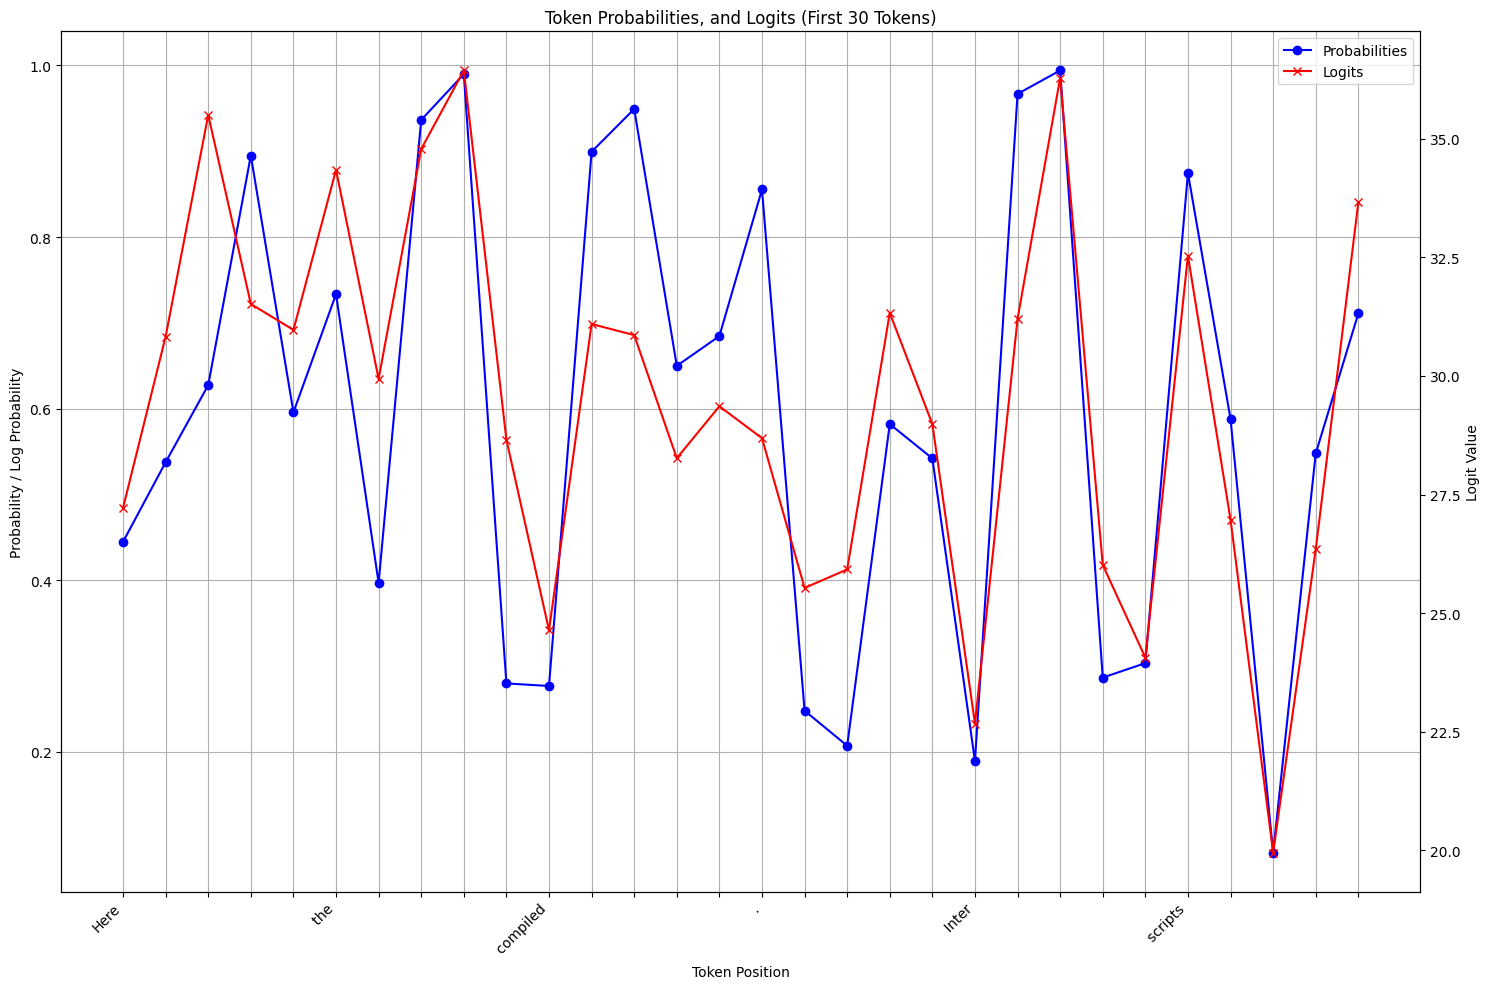

In [ ]:
# Plot probabilities, logprobs, and logits from the first row of df_v1 (first 20 tokens only)

number_tokens = 30

# Extract data from the first row (limit to first 20 tokens)
first_tokens = df_07['tokens'][0][:number_tokens]
first_probs = df_07['probs'][0][:number_tokens]
first_logprobs = df_07["logprobs"][0][:number_tokens]
first_logits = df_07['logits'][0][:number_tokens]

# Create figure with a single plot
fig, ax = plt.subplots(figsize=(15, 10))

# Create a second y-axis for logits (which have a different scale)
ax2 = ax.twinx()

# Plot probabilities and logprobs on the first y-axis
ax.plot(first_probs, marker='o', linestyle='-', color='blue', label='Probabilities')
#ax.plot(first_logprobs, marker='^', linestyle='-', color='green', label='Log Probabilities')

# Plot logits on the second y-axis
ax2.plot(first_logits, marker='x', linestyle='-', color='red', label='Logits')

# Set titles and labels
ax.set_title(f'Token Probabilities, and Logits (First {number_tokens} Tokens)')
ax.set_xlabel('Token Position')
ax.set_ylabel('Probability / Log Probability')
ax2.set_ylabel('Logit Value')
ax.grid(True)

# Add token labels to x-axis (for every 5th token to avoid overcrowding)
token_positions = np.arange(len(first_tokens))
token_labels = [token if i % 5 == 0 else '' for i, token in enumerate(first_tokens)]
ax.set_xticks(token_positions)
ax.set_xticklabels(token_labels, rotation=45, ha='right')

# Add legends for both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
# Count number of 1.0 probabilities across all rows
print("temp 0.7")
total_ones = sum(prob_list.count(1.0) for prob_list in df_07['probs'])
ones_in_first_07 = df_07['probs'][0].count(1.0)
print(f"Number of tokens with probability 1.0: {total_ones}")
print(f"Number of tokens with probability 1.0 in first row: {ones_in_first_07}")

# Calculate percentage
total_tokens = sum(len(prob_list) for prob_list in df_07['probs'])
percent_ones = (total_ones / total_tokens) * 100
print(f"Percentage of tokens with probability 1.0: {percent_ones:.2f}%")

print("--------------------------------")

print("temp 0.7 no rounding")
total_ones = sum(prob_list.count(1.0) for prob_list in df_07_no_rounding['probs'])
ones_in_first_07 = df_07['probs'][0].count(1.0)
print(f"Number of tokens with probability 1.0: {total_ones}")
print(f"Number of tokens with probability 1.0 in first row: {ones_in_first_07}")

# Calculate percentage
total_tokens = sum(len(prob_list) for prob_list in df_07_no_rounding['probs'])
percent_ones = (total_ones / total_tokens) * 100
print(f"Percentage of tokens with probability 1.0: {percent_ones:.2f}%")

print("--------------------------------")

print("temp 1.2")
total_ones = sum(prob_list.count(1.0) for prob_list in df_12['probs'])
ones_in_first_12 = df_12['probs'][0].count(1.0)
print(f"Number of tokens with probability 1.0: {total_ones}")
print(f"Number of tokens with probability 1.0 in first row: {ones_in_first_12}")

# Calculate percentage
total_tokens = sum(len(prob_list) for prob_list in df_12['probs'])
percent_ones = (total_ones / total_tokens) * 100
print(f"Percentage of tokens with probability 1.0: {percent_ones:.2f}%")

print("--------------------------------")

print("temp 2.0")
# Count number of 1.0 probabilities across all rows
total_ones = sum(prob_list.count(1.0) for prob_list in df_20['probs'])
ones_in_first_20 = df_20['probs'][0].count(1.0)
print(f"Number of tokens with probability 1.0: {total_ones}")
print(f"Number of tokens with probability 1.0 in first row: {ones_in_first_20}")

# Calculate percentage
total_tokens = sum(len(prob_list) for prob_list in df_20['probs'])
percent_ones = (total_ones / total_tokens) * 100
print(f"Percentage of tokens with probability 1.0: {percent_ones:.2f}%")



temp 0.7
Number of tokens with probability 1.0: 35938
Number of tokens with probability 1.0 in first row: 101
Percentage of tokens with probability 1.0: 39.55%
--------------------------------
temp 0.7 no rounding
Number of tokens with probability 1.0: 6385
Number of tokens with probability 1.0 in first row: 101
Percentage of tokens with probability 1.0: 37.94%
--------------------------------
temp 1.2
Number of tokens with probability 1.0: 27195
Number of tokens with probability 1.0 in first row: 46
Percentage of tokens with probability 1.0: 20.08%
--------------------------------
temp 2.0
Number of tokens with probability 1.0: 41
Number of tokens with probability 1.0 in first row: 0
Percentage of tokens with probability 1.0: 0.11%
